# Telco Customer Churn Prediction

## Project Overview

This project develops a machine learning classification system to predict whether a telecommunications customer is likely to churn.

The objective is to identify customers who may be at higher risk of leaving so that a retention team can prioritize proactive customer engagement.

The project covers:

- Data cleaning
- Exploratory data analysis
- Feature preparation
- Class imbalance handling
- Model training
- Cross-validation
- Model comparison
- Hyperparameter tuning
- Model evaluation
- Feature importance
- Individual customer prediction
- Model deployment preparation

### Dataset

IBM Telco Customer Churn dataset containing 7,043 customers and 21 columns.

### Models

- Decision Tree
- Random Forest
- XGBoost

### Evaluation Metrics

Because the dataset contains more non-churn customers than churn customers, accuracy alone is not sufficient.

The main evaluation metrics are:

- Recall
- Precision
- F1-score
- ROC-AUC

## Contents

1. Business problem
2. Data overview
3. Data cleaning
4. Exploratory data analysis
5. Preprocessing and train/test split
6. Model comparison (cross-validation)
7. Hyperparameter tuning
8. Final evaluation on the test set
9. Feature importance
10. Business recommendations
11. Saving the model and making predictions
12. Limitations, next steps and conclusion


## 1. Business Problem

Customer churn is an important business problem for telecommunications companies because losing customers can reduce recurring revenue and increase the need to acquire replacement customers.

The objective of this project is to predict which customers are likely to churn based on their demographic, service, contract and billing information.

### Business Question

> Which customers are most likely to churn, and what characteristics are associated with higher churn risk?

### Business Use Case

The model can be used as a prioritization tool for a customer retention team.

Customers with a high predicted probability of churn could be reviewed for appropriate retention strategies.

The model should support business decision-making rather than automatically determine which customers receive an intervention.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC


RANDOM_STATE = 42
DATA_PATH = "Telco-Customer-Churn.csv"
MODEL_PATH = "churn_pipeline.joblib"
IMAGES_DIR = "images"
os.makedirs(IMAGES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Data Overview

Each row represents one customer. The columns fall into five groups:

| Group | Columns |
|---|---|
| Demographics | gender, SeniorCitizen, Partner, Dependents |
| Account | tenure, Contract, PaperlessBilling, PaymentMethod |
| Services | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| Charges | MonthlyCharges, TotalCharges |
| Target | Churn (Yes / No) |

The first step is to load the data and check its size, column types and first rows.

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Cleaning

Before modelling, the dataset needs to be checked for:

- Missing values
- Incorrect data types
- Duplicate records
- Identifier columns that should not be used as predictive features
- Inconsistent values

The `customerID` column is an identifier rather than a useful predictive feature, so it will be removed.

The `TotalCharges` column contains blank string values. These values are investigated before conversion to numeric format.

In [7]:
print("Duplicated customerIDs:", df["customerID"].duplicated().sum())

Duplicated customerIDs: 0


In [8]:
df = df.drop(columns=["customerID"])

In [9]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
print("Rows identical on all features (after dropping customerID):", df.duplicated().sum())

Rows identical on all features (after dropping customerID): 22


In [11]:
print("Blank TotalCharges values:", (df["TotalCharges"] == " ").sum())

Blank TotalCharges values: 11


In [12]:
print(
    "Tenure values for blank TotalCharges:",
    df.loc[df["TotalCharges"] == " ", "tenure"].unique()
)

Tenure values for blank TotalCharges: [0]


In [13]:
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"}).astype(float)

### Cleaning Results

- `customerID` values are unique (0 duplicated IDs), so no customer appears twice. The column was then removed because it is an identifier, not a customer characteristic that the model should learn from.
- After removing `customerID`, 22 rows are identical on every other feature. They belong to different customers with the same profile, so they are kept.
- `isnull()` found no missing values, but `TotalCharges` contained 11 blank text values that were hidden as strings.
- All 11 of those customers have `tenure = 0` (new customers who have not been billed yet), so the blanks were converted to `0.0`.
- `TotalCharges` is now numeric, which the `info()` output below confirms.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### Category values check

The next cell prints the unique values of every non-numeric column to confirm that categories are consistent (for example, `No phone service` and `No internet service` are separate categories, not typos).

In [15]:
numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col,df[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

## 4. Exploratory Data Analysis

The goal of this section is to understand the data and to find which customer characteristics are related to churn.

### 4.1 Target distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


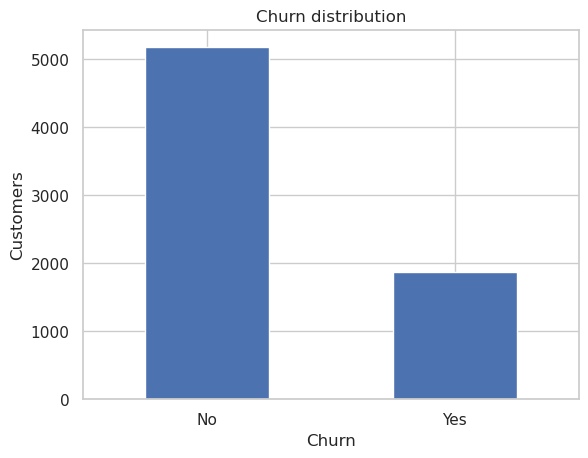

In [16]:
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(3))

df["Churn"].value_counts().plot(kind="bar", rot=0, title="Churn distribution")
plt.ylabel("Customers")
plt.show()

About 26.5% of customers churned, while 73.5% remained with the company. The classes are imbalanced, so a model that predicted “No churn” for every customer would already achieve about 73.5% accuracy. Therefore, accuracy alone is not enough to evaluate the churn model.

### 4.2 Numeric features

Summary statistics, distributions and outliers for `tenure`, `MonthlyCharges` and `TotalCharges`.

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [18]:
def plot_histogram(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    
    plt.axvline(col_mean,color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="-", label="Median")

    plt.legend()
    
    plt.show()

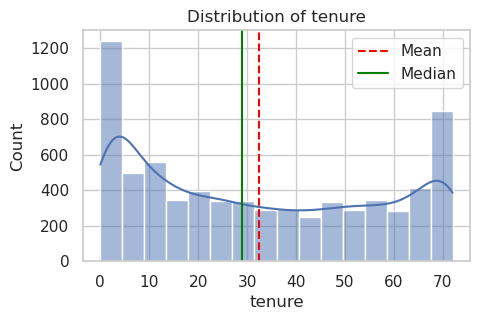

In [19]:
plot_histogram(df,"tenure")

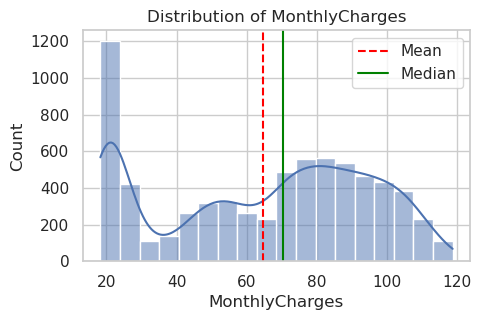

In [20]:
plot_histogram(df,"MonthlyCharges")

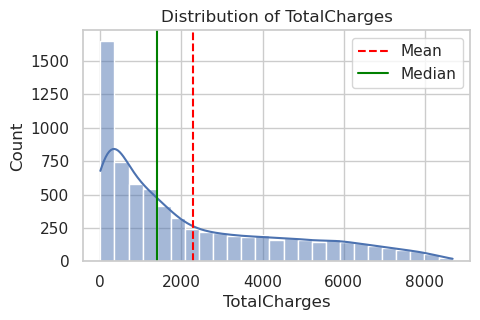

In [21]:
plot_histogram(df,"TotalCharges")

In [22]:
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Box plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

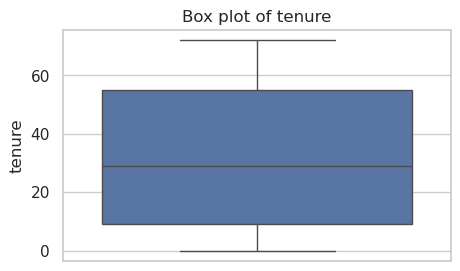

In [23]:
plot_boxplot(df,"tenure")

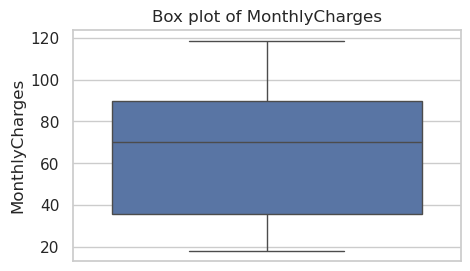

In [24]:
plot_boxplot(df,"MonthlyCharges")

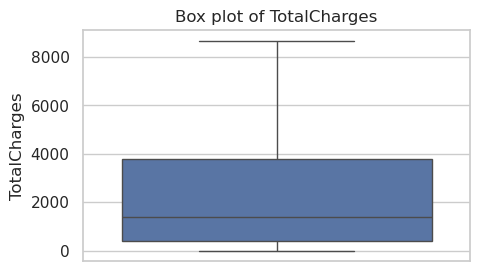

In [25]:
plot_boxplot(df,"TotalCharges")

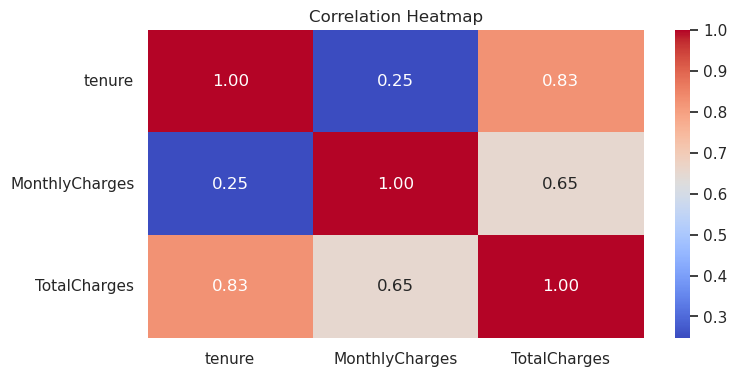

In [26]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The numeric features show several useful patterns. Tenure and TotalCharges have a strong positive relationship because customers who stay longer generally accumulate higher total charges. MonthlyCharges show variation across customers, reflecting differences in the services and plans they use. The boxplots also show differences in the distributions and highlight some potential outliers.

### 4.3 Churn rate by feature

Raw counts only show how many customers are in each category. The **churn rate** (share of customers who left) shows which categories are risky. The plots below are the most important part of the analysis.

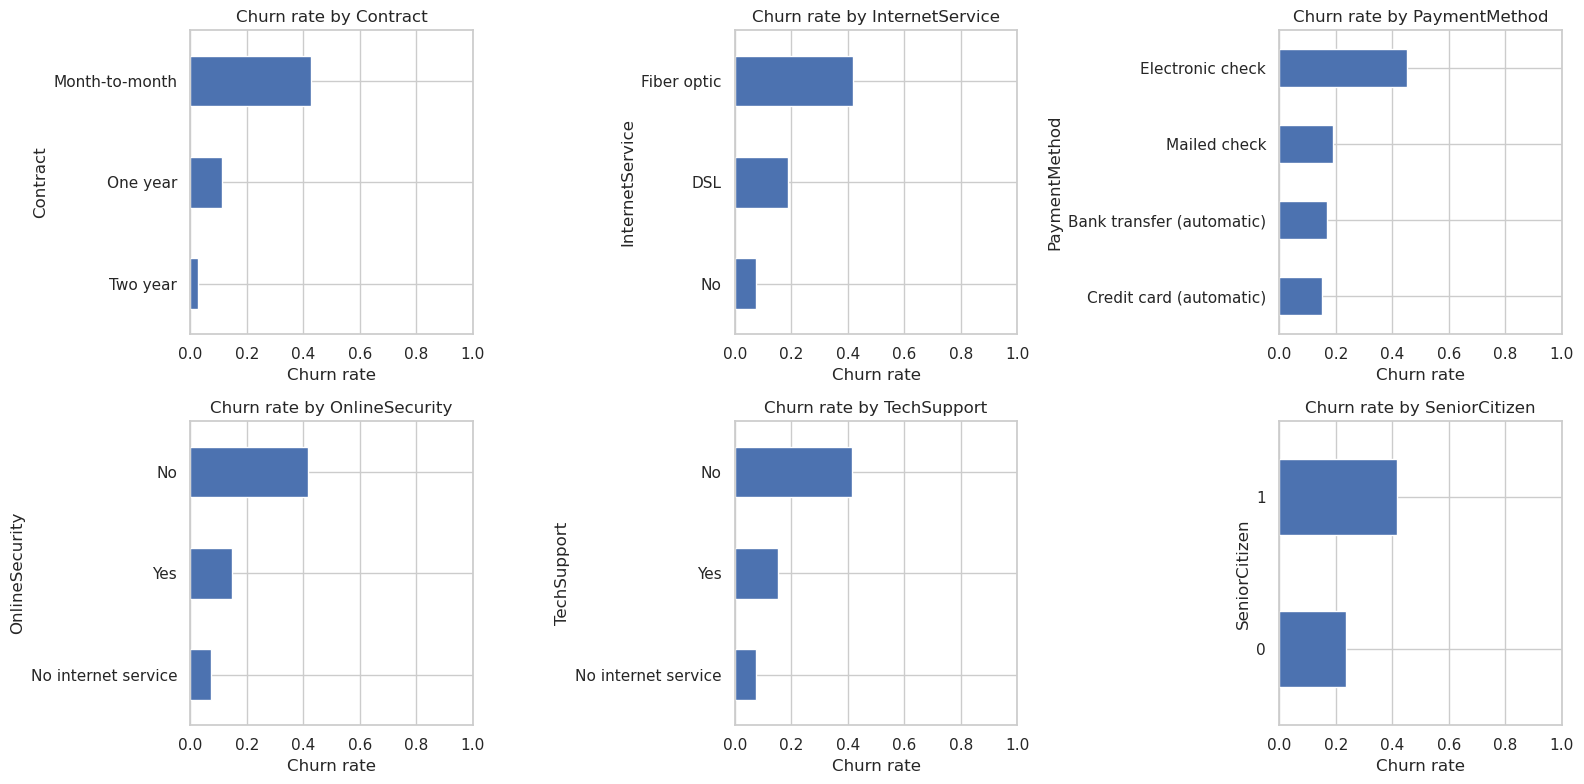

In [27]:
key_cats = ["Contract", "InternetService", "PaymentMethod",
            "OnlineSecurity", "TechSupport", "SeniorCitizen"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), key_cats):
    rate = (df["Churn"] == "Yes").groupby(df[col]).mean().sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/churn_rate_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.6            61.3        2549.9
Yes      18.0            74.4        1531.8


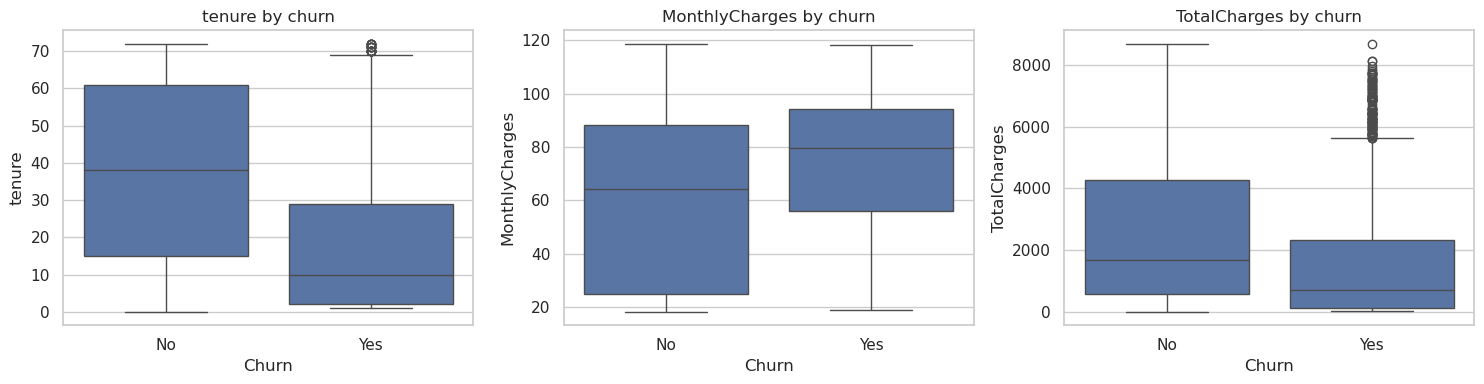

In [28]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print(df.groupby("Churn")[num_cols].mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

### 4.4 Key insights

1. Month-to-month customers have a much higher churn rate than customers on longer contracts.
2. Customers with shorter tenure tend to have a higher risk of churn.
3. Fiber optic customers show a higher churn rate than DSL and customers without internet service.
4. Electronic check customers account for a large share of churned customers.
5. Customers without online security or technical support show higher churn compared with customers who have these services.

## 5. Preprocessing and Train/Test Split

To avoid data leakage, the work is done in this order:

1. Convert the target to 0/1 and split the data **first** (80% train, 20% test). The split is stratified so both parts keep the same churn ratio.
2. Encode the categorical features and balance the classes **inside a pipeline**, so both steps are fitted on training data only.

Categorical features are ordinal-encoded because the models are tree-based and do not assume any order between categories. Class imbalance is handled with `SMOTENC`, a version of SMOTE that understands categorical columns, so it does not invent impossible category values.

The test set is not touched again until the final evaluation.

In [29]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate in train:", round(y_train.mean(), 3), "| in test:", round(y_test.mean(), 3))

Train: (5634, 19) | Test: (1409, 19)
Churn rate in train: 0.265 | in test: 0.265


In [30]:
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

preprocess = ColumnTransformer(
    [("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols)],
    remainder="passthrough",
)

def make_pipe(model):
    """Encoding -> SMOTENC -> model. Every step is fitted on training data only."""
    return ImbPipeline([
        ("preprocess", clone(preprocess)),
        # the categorical columns are the first len(cat_cols) columns after the ColumnTransformer
        ("smote", SMOTENC(categorical_features=list(range(len(cat_cols))),
                          random_state=RANDOM_STATE)),
        ("model", clone(model)),
    ])

print("Categorical columns:", len(cat_cols))

Categorical columns: 15


## 6. Model Comparison

A dummy classifier that predicts the most frequent class is used as a baseline. Every real model must beat it on recall and F1, not only on accuracy.

Models are compared with stratified 5-fold cross-validation on the **training set only**. Because `SMOTENC` is inside the pipeline, each validation fold contains only real customers, so the scores are not inflated by synthetic rows.

In [31]:
models = {
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = {}
for name, model in models.items():
    print(f"Cross-validating {name}...")
    scores = cross_validate(make_pipe(model), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows[name] = {m: scores[f"test_{m}"].mean() for m in scoring}

cv_results = pd.DataFrame(cv_rows).T.round(3)
cv_results

Cross-validating Dummy (baseline)...
Cross-validating Decision Tree...
Cross-validating Random Forest...
Cross-validating XGBoost...


,accuracy,precision,recall,f1,roc_auc
Dummy (baseline),0.735,0.000,0.000,0.000,0.500
Decision Tree,0.726,0.486,0.553,0.517,0.671
Random Forest,0.781,0.589,0.579,0.583,0.819
XGBoost,0.771,0.567,0.583,0.575,0.820


The Random Forest model performs better than the Decision Tree, achieving a cross-validation accuracy of 0.781 and an F1 score of 0.583. The Decision Tree has a lower F1 score of 0.517, while the dummy model achieves 0.735 accuracy but has zero recall. This shows why accuracy alone is not sufficient for evaluating the churn models.

## 7. Hyperparameter Tuning

Random Forest and XGBoost are tuned with randomized search (15 random combinations each), optimizing **F1 for the churn class** with the same cross-validation setup. The tuning uses the training set only. The model with the higher cross-validated F1 is selected.

This step can take a few minutes.

In [32]:
param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", 0.5],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
    },
}

searches = {}
for name, grid in param_grids.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        make_pipe(models[name]), grid, n_iter=15, scoring="f1",
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"  best CV F1: {search.best_score_:.3f}")
    print(f"  best params: {search.best_params_}")

best_name = max(searches, key=lambda n: searches[n].best_score_)
best_model = searches[best_name].best_estimator_
print("\nSelected model:", best_name)

Tuning Random Forest...
  best CV F1: 0.628
  best params: {'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Tuning XGBoost...
  best CV F1: 0.628
  best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

Selected model: Random Forest


Hyperparameter tuning improved the Random Forest cross-validation F1 score from 0.583 to 0.628. The selected settings used 300 trees, a maximum depth of 8, a minimum of 5 samples per leaf, and the square-root feature setting. XGBoost also achieved an F1 score of 0.628, resulting in a tie between the two models.

## 8. Final Evaluation on the Test Set

The test set has not been used for any decision so far. The table compares the default models with the tuned model on the same unseen customers.

In [33]:
def evaluate(name, pipe):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Churn precision": precision_score(y_test, y_pred, zero_division=0),
        "Churn recall": recall_score(y_test, y_pred),
        "Churn F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

comparison = []
for name, model in models.items():
    fitted = make_pipe(model).fit(X_train, y_train)
    comparison.append(evaluate(f"{name} (default)", fitted))
comparison.append(evaluate(f"{best_name} (tuned)", best_model))

comparison_df = pd.DataFrame(comparison).set_index("Model").round(3)
comparison_df

,Accuracy,Churn precision,Churn recall,Churn F1,ROC-AUC
Model,,,,,
Dummy (baseline) (default),0.735,0.000,0.000,0.000,0.500
Decision Tree (default),0.714,0.466,0.535,0.498,0.657
Random Forest (default),0.772,0.569,0.583,0.576,0.816
XGBoost (default),0.776,0.571,0.626,0.597,0.817
Random Forest (tuned),0.773,0.558,0.695,0.619,0.832


In [34]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.88      0.80      0.84      1035
       Churn       0.56      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



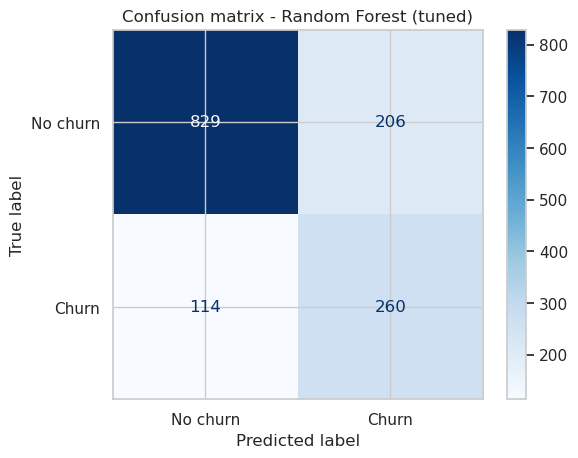

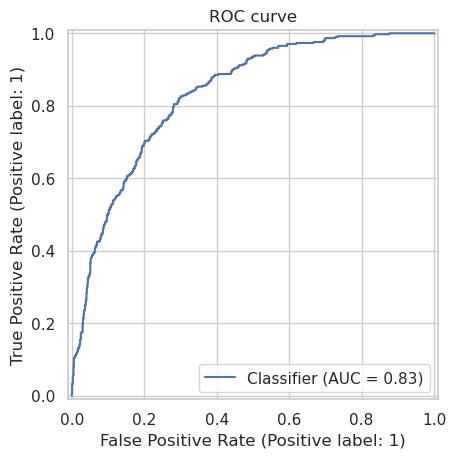

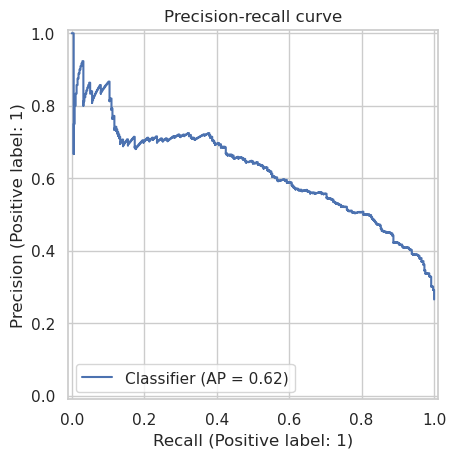

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No churn", "Churn"], cmap="Blues"
)
plt.title(f"Confusion matrix - {best_name} (tuned)")
plt.savefig(f"{IMAGES_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC curve")
plt.savefig(f"{IMAGES_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-recall curve")
plt.savefig(f"{IMAGES_DIR}/pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

- Recall was 0.695, meaning the model identified about 69.5% of customers who actually churned.
- Precision was 0.558, meaning about 55.8% of customers predicted to churn actually churned.
- The ROC-AUC was 0.832, showing good separation between customers who churn and those who stay.
- Accuracy was 0.773, compared with a dummy-model recall of 0.

Interpretation: If the model flags 100 customers as likely to churn, approximately 56 of them would actually leave.

## 9. Feature Importance

Feature importance shows which inputs the selected model relies on most. It shows **which** features matter, not **in which direction** they push the prediction.

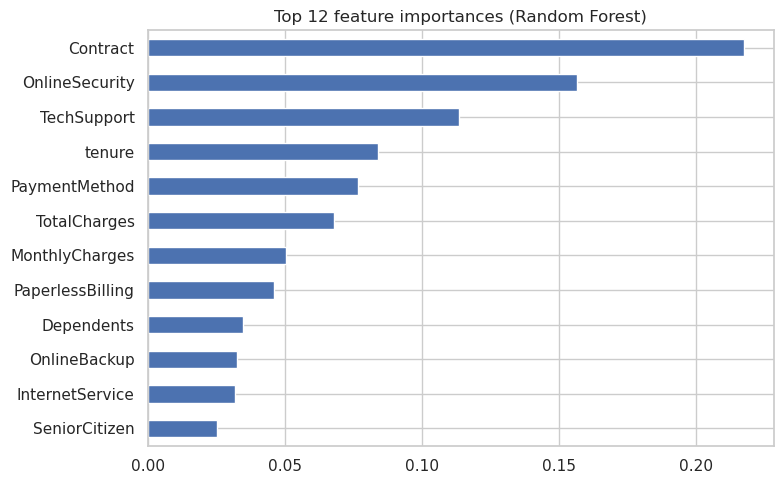

In [36]:
feature_names = [n.split("__", 1)[1]
                 for n in best_model.named_steps["preprocess"].get_feature_names_out()]
importances = pd.Series(
    best_model.named_steps["model"].feature_importances_, index=feature_names
).sort_values()

importances.tail(12).plot(kind="barh", figsize=(8, 5),
                          title=f"Top 12 feature importances ({best_name})")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

The most important features are Contract, OnlineSecurity, TechSupport, tenure and PaymentMethod. This agrees with the exploratory analysis where contract type and shorter tenure were associated with higher churn rates. Feature importance shows which variables the model relies on most, while SHAP values could be used as a next step to understand the direction of each effect.

## 10. Business Recommendations

1. Target customers on month-to-month contracts with retention offers or incentives to encourage longer-term contracts.

2. Prioritize customers with shorter tenure for early engagement, personalized support, and retention campaigns.

3. Focus retention efforts on customers using fiber optic services, particularly where other risk factors indicate a higher likelihood of churn.

4. Contact customers who use electronic check payments and offer alternative payment options together with retention incentives.

5. Use the model as a prioritisation tool.

## 11. Saving the Model and Making Predictions

The whole pipeline (encoding and model) is saved as **one file**. New customer data can be scored directly, and no separate encoder file is needed.

In [37]:
os.makedirs(os.path.dirname(MODEL_PATH) or ".", exist_ok=True)
joblib.dump(best_model, MODEL_PATH)
print("Saved:", MODEL_PATH)

def predict_churn(customer, model=None, threshold=0.5):
    """Return the churn probability and label for one customer (a dict of raw feature values)."""
    if model is None:
        model = joblib.load(MODEL_PATH)
    proba = model.predict_proba(pd.DataFrame([customer]))[0, 1]
    return {
        "churn_probability": round(float(proba), 3),
        "prediction": "Churn" if proba >= threshold else "No churn",
    }

Saved: churn_pipeline.joblib


In [38]:
input_data = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85,
}

predict_churn(input_data)

{'churn_probability': 0.66, 'prediction': 'Churn'}

## 12. Limitations, Next Steps and Conclusion

### Limitations

- The data is a single snapshot of customers, so the model cannot capture how behaviour changes over time.
- `SMOTENC` creates synthetic customers, which may not perfectly reflect real customers. Comparing it with `class_weight="balanced"` would be a useful check.
- The 0.5 decision threshold is a default. A real deployment should choose the threshold from the cost of a retention offer versus the value of a saved customer.
- There is no cost-benefit analysis of retention actions in this project.

### Next steps

- SHAP explanations for individual predictions
- Probability calibration and business-driven threshold selection
- A small Streamlit app that calls `predict_churn`
- Monitoring for data drift after deployment

### Conclusion

The final model is the Random Forest, with recall of 0.695, F1 score of 0.619, and ROC-AUC of 0.832. The most important factors identified by the model are Contract, OnlineSecurity, TechSupport, tenure and PaymentMethod. These findings suggest that the business should focus retention efforts on customers showing these risk characteristics and use the model to prioritize customers for intervention.

### Library versions used

Copy these into `requirements.txt` for the GitHub repository.

In [39]:
import sklearn, imblearn, xgboost

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)
print("scikit-learn", sklearn.__version__)
print("imbalanced-learn", imblearn.__version__)
print("xgboost", xgboost.__version__)
print("joblib", joblib.__version__)

numpy 1.26.4
pandas 2.3.3
matplotlib 3.10.6
seaborn 0.13.2
scikit-learn 1.7.2
imbalanced-learn 0.14.0
xgboost 3.4.1
joblib 1.5.2
